EDA（Exploratory Data Analysis，探索性数据分析）

导入模块

In [1]:
import pandas as pd

加载数据

In [3]:
data = pd.read_csv("../data/raw/sales_data.csv")

# 1. 数据质量分析

## 1.1. 基础统计分析

查看数据摘要信息

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

查看数据统计描述

In [3]:
data.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


查看数据行数

In [4]:
len(data)

76000

查看数据的前五行

In [4]:
data.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


查看数据的维度

In [5]:
data.shape

(76000, 16)

查看数据的列名

In [6]:
data.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

查看各字段数据类型

In [8]:
data.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

直方图

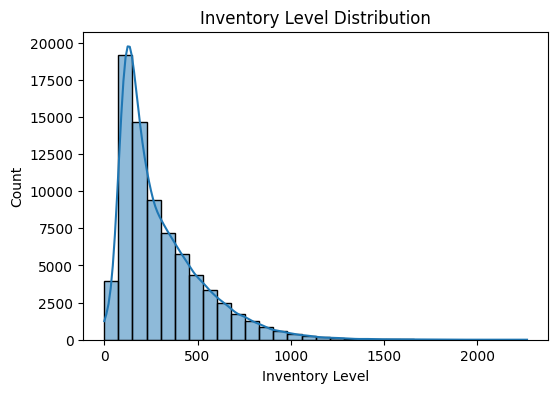

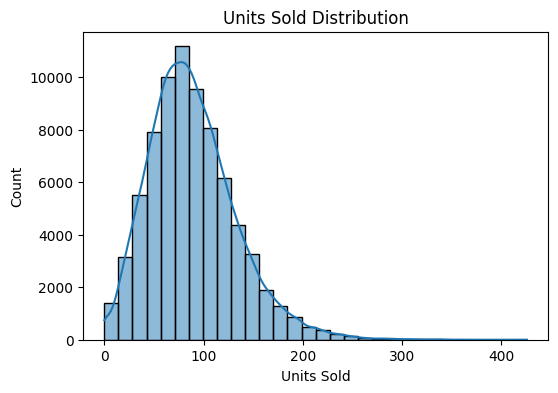

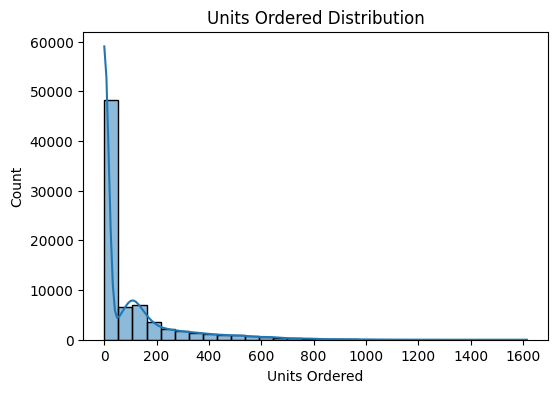

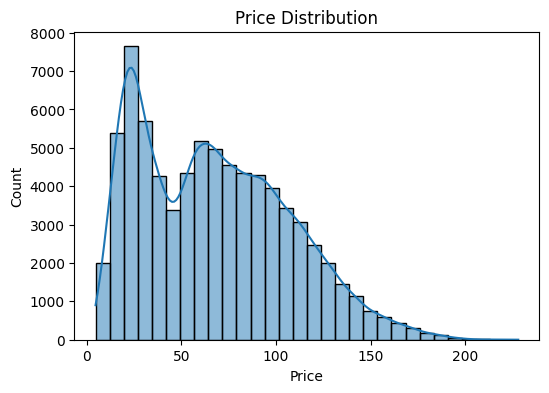

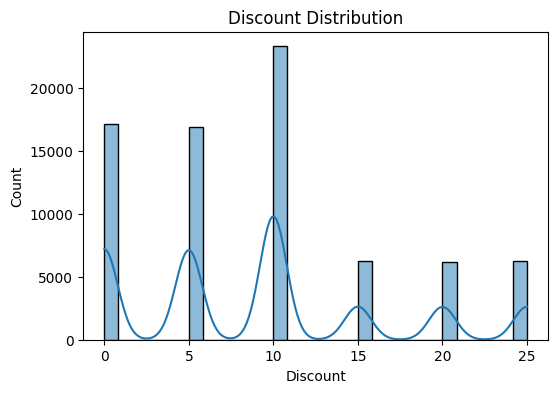

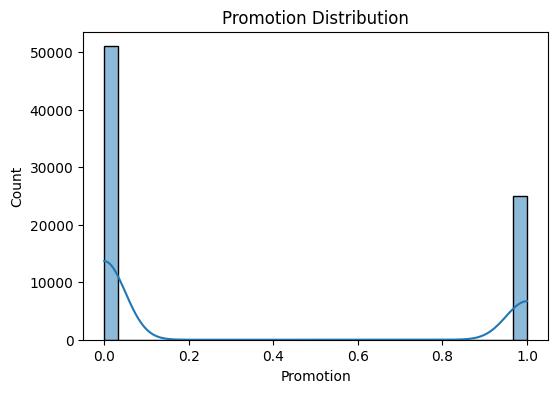

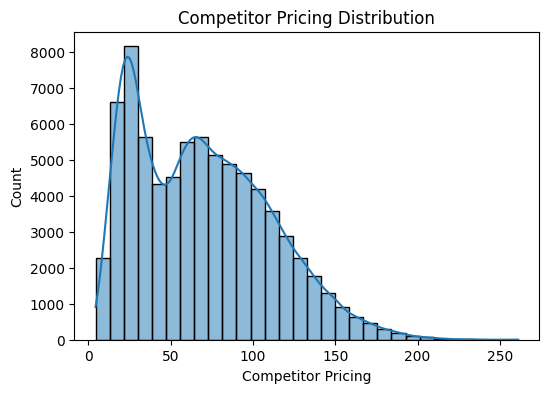

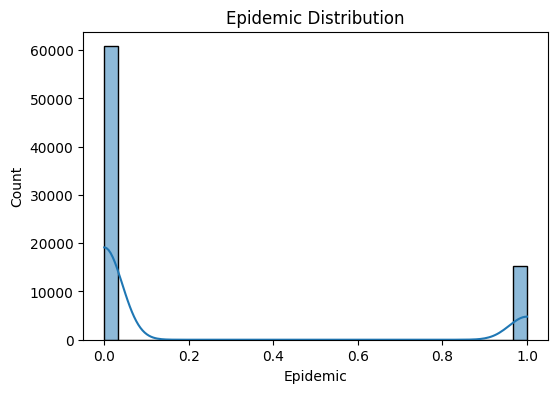

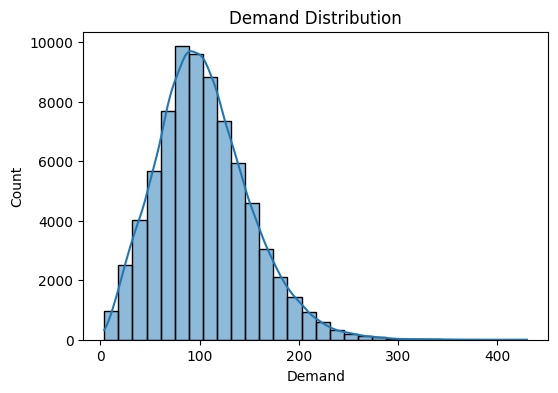

In [6]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'{col} Distribution')
    plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设数据集叫 data
# 自动获取数值型列
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# 计算 CV
cv_values = data[num_cols].std() / data[num_cols].mean()

# 转为 DataFrame 方便可视化
cv_df = cv_values.reset_index()
cv_df.columns = ['Variable', 'CV']

print(cv_df)

             Variable        CV
0     Inventory Level  0.752368
1          Units Sold  0.495281
2       Units Ordered  1.822914
3               Price  0.581429
4            Discount  0.822686
5           Promotion  1.428295
6  Competitor Pricing  0.589510
7            Epidemic  2.000013
8              Demand  0.450212


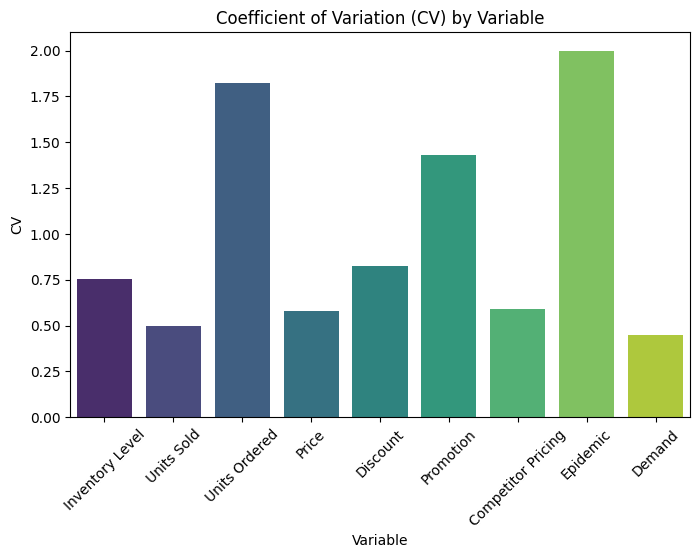

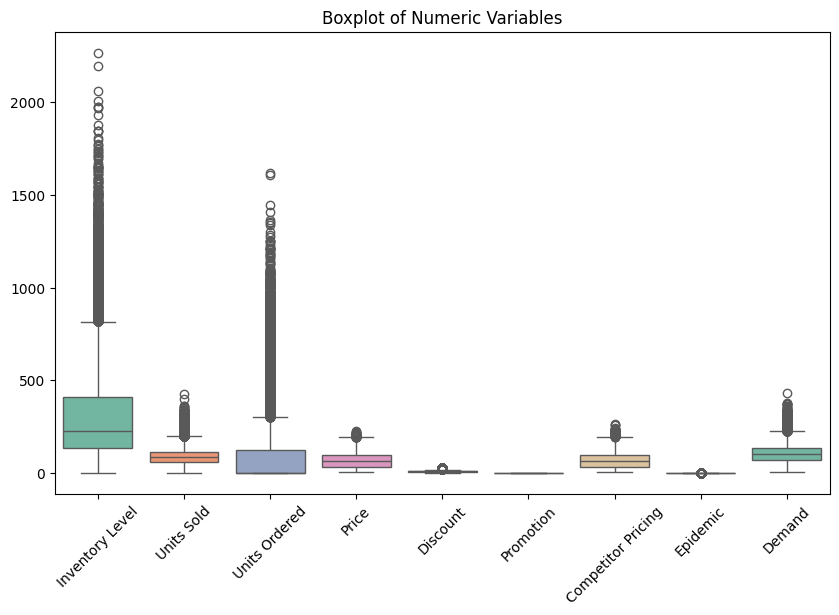

In [5]:
# 1. 绘制 CV 条形图
plt.figure(figsize=(8,5))
sns.barplot(x="Variable", y="CV", hue="Variable", data=cv_df, palette="viridis", legend=False)
plt.title("Coefficient of Variation (CV) by Variable")
plt.ylabel("CV")
plt.xticks(rotation=45)
plt.show()

# 2. 绘制每个数值列的箱线图，直观展示离散程度
plt.figure(figsize=(10,6))
sns.boxplot(data=data[num_cols], palette="Set2")
plt.title("Boxplot of Numeric Variables")
plt.xticks(rotation=45)
plt.show()

## 1.2. 缺失值分析
如果有缺失值，需要进行缺失值处理

In [7]:
data.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

## 1.3. 异常值分析
异常值（离群值）

### 1.3.1. 统计量分析法

#### Z-score方法
Z-score 是衡量每个数据点距离均值多少个标准差的一个统计量。通常，绝对值大于 3 的 Z-score 值表示该数据点为异常值。
- 数据服从正态分布，使用3$\sigma$原则，$P(|x-\mu|>3\sigma)\leq0.003$

In [9]:
from scipy import stats

In [11]:
# 计算 Z-score
z_scores = stats.zscore(data.select_dtypes(include=['float64', 'int64']))
z_scores

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
0,-0.468251,0.299418,1.003114,0.126823,-0.546708,-0.700140,0.397522,-0.5,0.227466
1,-0.812608,0.640372,0.984642,0.315762,0.790954,1.428286,0.551148,-0.5,2.654832
2,-0.238679,0.572181,3.219815,-0.121542,0.122123,1.428286,-0.228950,-0.5,1.121759
3,-0.715482,-0.996206,0.079489,0.505464,0.122123,-0.700140,0.384333,-0.5,-1.113973
4,-0.658089,-0.541601,1.120107,-0.338162,-1.215538,-0.700140,-0.435332,-0.5,-0.964924
...,...,...,...,...,...,...,...,...,...
75995,-0.300487,-0.587061,-0.548576,-0.963136,-0.546708,-0.700140,-0.909155,-0.5,-0.858460
75996,-0.724312,0.594912,0.319632,-0.629952,-0.546708,-0.700140,-0.701552,-0.5,0.695905
75997,-0.459421,-1.018936,-0.548576,-1.267624,0.122123,-0.700140,-1.222269,-0.5,-0.773290
75998,-0.777290,-0.700713,-0.548576,2.133037,-1.215538,-0.700140,1.813618,-0.5,-0.432607


In [16]:
# 筛选 Z-score 大于 3 的值
abs_z_scores = abs(z_scores)
print('type of abs_z_scores: ', type(abs_z_scores))
outliers = (abs_z_scores > 3).all(axis=1)
outliers

type of abs_z_scores:  <class 'pandas.core.frame.DataFrame'>


0        False
1        False
2        False
3        False
4        False
         ...  
75995    False
75996    False
75997    False
75998    False
75999    False
Length: 76000, dtype: bool

In [13]:
# 输出异常值所在行
data_outliers = data[outliers]
print(data_outliers)

Empty DataFrame
Columns: [Date, Store ID, Product ID, Category, Region, Inventory Level, Units Sold, Units Ordered, Price, Discount, Weather Condition, Promotion, Competitor Pricing, Seasonality, Epidemic, Demand]
Index: []


#### IQR 方法（四分位数间距法）
IQR 方法基于数据的四分位数，认为落在 Q1 - 1.5 * IQR 和 Q3 + 1.5 * IQR 之外的值为异常值。Q1 是第 25 百分位数，Q3 是第 75 百分位数，IQR = Q3 - Q1。

In [3]:
numeric_data = data.select_dtypes(include='number')
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1
IQR

Inventory Level       272.0000
Units Sold             56.0000
Units Ordered         121.0000
Price                  63.8325
Discount                5.0000
Promotion               1.0000
Competitor Pricing     65.3125
Epidemic                0.0000
Demand                 62.0000
dtype: float64

In [4]:
# 计算异常值的上下边界
lower_bound = Q1 - 1.5 * IQR  # 下边界
print(lower_bound)
upper_bound = Q3 + 1.5 * IQR  # 上边界
print(upper_bound)

Inventory Level      -272.00000
Units Sold            -26.00000
Units Ordered        -181.50000
Price                 -63.75125
Discount               -2.50000
Promotion              -1.50000
Competitor Pricing    -65.34875
Epidemic                0.00000
Demand                -22.00000
dtype: float64
Inventory Level       816.00000
Units Sold            198.00000
Units Ordered         302.50000
Price                 191.57875
Discount               17.50000
Promotion               2.50000
Competitor Pricing    195.90125
Epidemic                0.00000
Demand                226.00000
dtype: float64


In [6]:
outliers = (numeric_data < lower_bound) | (numeric_data > upper_bound)
data_outliers = data[outliers.any(axis=1)]
data_outliers

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
13,2022-01-01,S001,P0014,Groceries,North,252,121,479,80.13,10,Snowy,1,92.24,Winter,0,165
15,2022-01-01,S001,P0016,Groceries,North,103,78,372,38.79,10,Snowy,0,35.14,Winter,0,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75934,2024-01-30,S002,P0015,Clothing,South,1039,56,0,62.11,0,Snowy,0,70.65,Winter,0,67
75953,2024-01-30,S003,P0014,Groceries,East,350,162,400,119.68,0,Sunny,0,102.56,Winter,0,157
75963,2024-01-30,S004,P0004,Groceries,West,439,151,451,62.88,0,Snowy,0,56.87,Winter,0,132
75981,2024-01-30,S005,P0002,Electronics,North,156,122,408,49.68,0,Snowy,0,45.77,Winter,0,136


In [7]:
outlier_counts = outliers.sum()
outlier_ratio = outlier_counts / len(data)
outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Ratio': outlier_ratio
}).sort_values(by='Outlier Count', ascending=False)
print(outlier_summary)

                    Outlier Count  Outlier Ratio
Epidemic                    15200       0.200000
Discount                    12413       0.163329
Units Ordered                7524       0.099000
Inventory Level              2759       0.036303
Units Sold                   1411       0.018566
Demand                        986       0.012974
Competitor Pricing            185       0.002434
Price                          70       0.000921
Promotion                       0       0.000000


箱线图

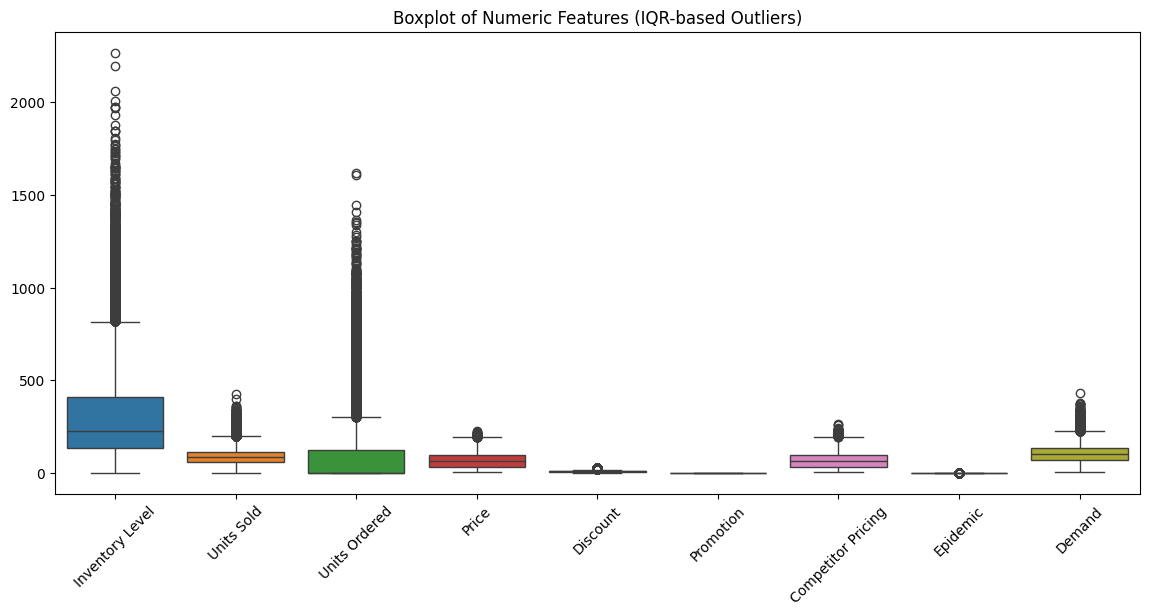

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_data)
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Features (IQR-based Outliers)")
plt.show()

## 1.4. 重复值分析

In [20]:
duplicates = data.duplicated()

# 输出重复的行数
print(f"重复的行数: {duplicates.sum()}")

重复的行数: 0


## 1.5. 一致性分析

In [3]:
inconsistent_sales = data[data['Units Sold'] > data['Inventory Level']]
print(f"销量大于库存的记录数: {len(inconsistent_sales)}")

销量大于库存的记录数: 0


In [4]:
high_stock_orders = data[(data['Inventory Level'] > data['Inventory Level'].quantile(0.9)) & (data['Units Ordered'] > 0)]
print(f"高库存仍然补货的记录数: {len(high_stock_orders)}")

高库存仍然补货的记录数: 572


In [5]:
invalid_discount = data[(data['Discount'] < 0) | (data['Discount'] > data['Price'])]
print(f"折扣异常的记录数: {len(invalid_discount)}")

折扣异常的记录数: 2739


In [10]:
# 查看部分异常记录
invalid_discount[['Price', 'Discount']].head(10)

# 统计异常占比
invalid_ratio = len(invalid_discount) / len(data)
print(f"异常折扣占比: {invalid_ratio:.2%}")

异常折扣占比: 3.60%


In [11]:
# 筛选折扣异常记录
invalid_discount = data[(data['Discount'] < 0) | (data['Discount'] > data['Price'])]

# 查看前 10 行
print("📌 折扣异常记录示例：")
print(invalid_discount[['Price', 'Discount']].head(10))

# 统计异常分布情况
print("\n📊 异常折扣的基本统计：")
print(invalid_discount[['Price', 'Discount']].describe())

# 按类型分类
print("\n🔍 异常分类：")
print("负折扣数量:", (invalid_discount['Discount'] < 0).sum())
print("大于价格的折扣数量:", (invalid_discount['Discount'] > invalid_discount['Price']).sum())

📌 折扣异常记录示例：
     Price  Discount
83    7.45        10
183   7.79        10
260  12.83        15
280  10.87        15
283   6.37        10
284  15.19        20
332  16.91        20
336  17.01        25
346  16.12        20
383   7.04        10

📊 异常折扣的基本统计：
             Price     Discount
count  2739.000000  2739.000000
mean     14.784925    20.755750
std       5.089641     5.134623
min       4.740000    10.000000
25%      10.365000    20.000000
50%      14.710000    20.000000
75%      18.825000    25.000000
max      24.990000    25.000000

🔍 异常分类：
负折扣数量: 0
大于价格的折扣数量: 2739


In [6]:
invalid_price = data[data['Price'] <= 0]
print(f"价格小于等于0的记录数: {len(invalid_price)}")

价格小于等于0的记录数: 0


In [7]:
duplicates = data[data.duplicated(subset=['Date','Store ID','Product ID'], keep=False)]
print(f"重复记录数: {len(duplicates)}")

重复记录数: 0


In [8]:
epidemic_stats = data.groupby('Epidemic')['Units Sold'].describe()
print(epidemic_stats)

            count       mean        std  min   25%   50%    75%    max
Epidemic                                                              
0         60800.0  95.819211  42.931063  0.0  66.0  90.0  120.0  426.0
1         15200.0  60.859737  36.436737  0.0  33.0  54.0   82.0  271.0


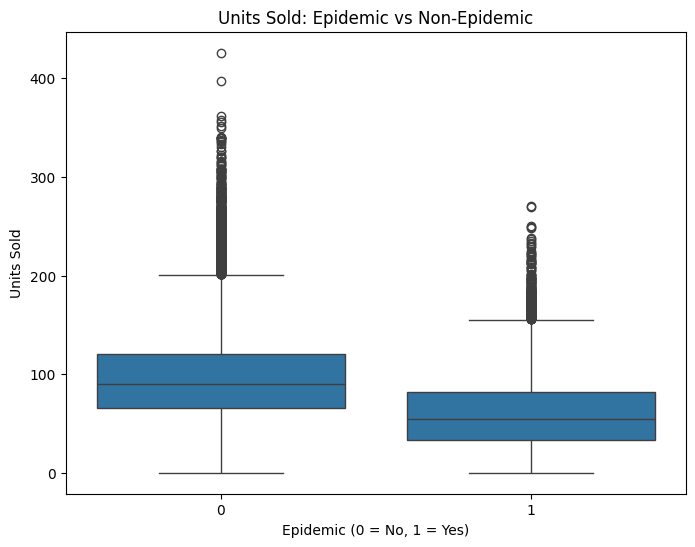

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Epidemic', y='Units Sold', data=data)
plt.title('Units Sold: Epidemic vs Non-Epidemic')
plt.xlabel('Epidemic (0 = No, 1 = Yes)')
plt.ylabel('Units Sold')
plt.show()

列 Inventory Level 的极端点数量：307


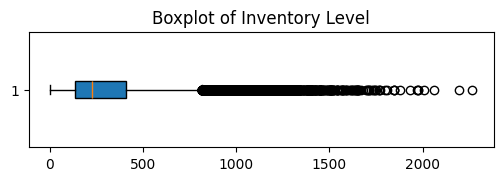

列 Units Sold 的极端点数量：81


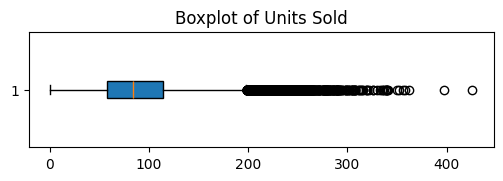

列 Units Ordered 的极端点数量：3377


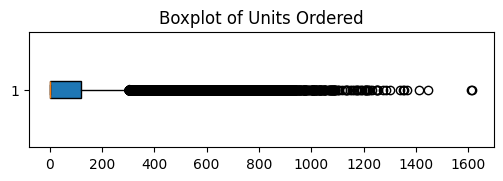

列 Price 的极端点数量：0


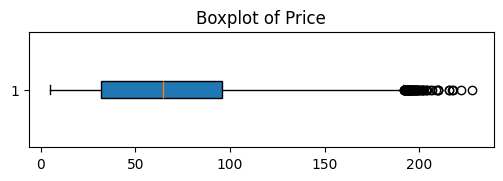

列 Discount 的极端点数量：0


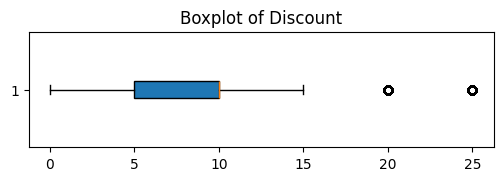

列 Competitor Pricing 的极端点数量：0


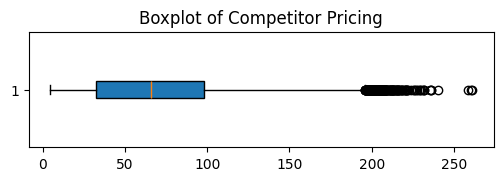

列 Demand 的极端点数量：36


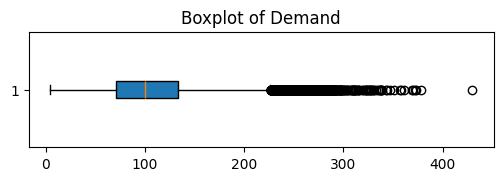

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 数值型列（根据你的数据结构）
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered',
                'Price', 'Discount', 'Competitor Pricing', 'Demand']

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    mild_lower = Q1 - 1.5 * IQR
    mild_upper = Q3 + 1.5 * IQR
    extreme_lower = Q1 - 3 * IQR
    extreme_upper = Q3 + 3 * IQR

    # 标记异常点与极端点
    data[f'{col}_is_mild_outlier'] = ((data[col] < mild_lower) | (data[col] > mild_upper))
    data[f'{col}_is_extreme_outlier'] = ((data[col] < extreme_lower) | (data[col] > extreme_upper))

    print(f"列 {col} 的极端点数量：{data[f'{col}_is_extreme_outlier'].sum()}")

    # 画箱线图
    plt.figure(figsize=(6, 1.5))
    plt.boxplot(data[col], vert=False, patch_artist=True)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [11]:
# 汇总所有极端点（任意数值列为极端点即算）
extreme_mask = data[[f'{col}_is_extreme_outlier' for col in numeric_cols]].any(axis=1)
extreme_points = data[extreme_mask]

print("极端点样本如下：")
print(extreme_points.head())

极端点样本如下：
          Date Store ID Product ID   Category Region  Inventory Level  \
2   2022-01-01     S001      P0003   Clothing  North              247   
22  2022-01-01     S002      P0003  Groceries  South              187   
43  2022-01-01     S003      P0004  Groceries   East              203   
46  2022-01-01     S003      P0007  Groceries   East              247   
52  2022-01-01     S003      P0013  Groceries   East              105   

    Units Sold  Units Ordered  Price  Discount  ...  \
2          114            612  62.94        10  ...   
22         167            596  95.17        10  ...   
43         122            518  26.29         5  ...   
46         123            552  18.65         0  ...   
52         105            743  86.78        10  ...   

   Units Ordered_is_mild_outlier  Units Ordered_is_extreme_outlier  \
2                           True                              True   
22                          True                              True   
43         

# 2. 数据特征分析

## 2.1. 趋势性分析